In [7]:
library(Signac)
library(dittoSeq)
library(Seurat)
library(gridExtra)
library(GenomicRanges)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
library(dplyr)
library(tidyr)
library(purrr)
library(future)

plan("multicore", workers = 32)
options(future.globals.maxSize = 100000 * 1024^3)

set.seed(1234)


Attaching package: 'purrr'


The following object is masked from 'package:XVector':

    compact


The following object is masked from 'package:GenomicRanges':

    reduce


The following object is masked from 'package:IRanges':

    reduce


The following object is masked from 'package:Signac':

    reduce




In [2]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Red Hat Enterprise Linux 8.6 (Ootpa)

Matrix products: default
BLAS/LAPACK: /gpfs/home3/cruiz2/miniconda3/envs/r_env_standr/lib/libopenblasp-r0.3.26.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] future_1.33.1                     dplyr_1.1.4                      
 [3] BSgenome.Hsapiens.UCSC.hg38_1.4.5 BSgenome_1.70.2                  
 [5] rtracklayer_1.62.0        

In [3]:
library(reticulate)
use_condaenv("multi_integration")


Attaching package: 'reticulate'


The following object is masked from 'package:rtracklayer':

    import


The following object is masked from 'package:BiocIO':

    import




## Create Seurat object from sampled h5ad 
Run only once!

In [7]:
sceasy::convertFormat('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/Mannens2024/Pool_peaks_subset.h5ad', 
                      from="anndata", to="seurat", assay='ATAC',
                       outFile='/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/Mannens2024/Pool_peaks_subset.rds')

X -> counts

Warning message:
"Key 'UMAP_' taken, using 'umap_' instead"


An object of class Seurat 
410863 features across 180724 samples within 1 assay 
Active assay: ATAC (410863 features, 0 variable features)
 2 layers present: counts, data
 19 dimensional reductions calculated: Embedding, LSI, LSI_b, LSI_main, TSNE, TSNE_1, TSNE_10, TSNE_2, TSNE_3, TSNE_4, TSNE_5, TSNE_bin, TSNE_main, TSNE_old, UMAP, UMAP3D, UMAP3D_main, UMAP_main, umap

## Loading reference and query

In [4]:
reference <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/data/Mannens2024/Pool_peaks_subset.rds')
reference

An object of class Seurat 
410863 features across 180724 samples within 1 assay 
Active assay: ATAC (410863 features, 0 variable features)
 2 layers present: counts, data
 19 dimensional reductions calculated: Embedding, LSI, LSI_b, LSI_main, TSNE, TSNE_1, TSNE_10, TSNE_2, TSNE_3, TSNE_4, TSNE_5, TSNE_bin, TSNE_main, TSNE_old, UMAP, UMAP3D, UMAP3D_main, UMAP_main, umap

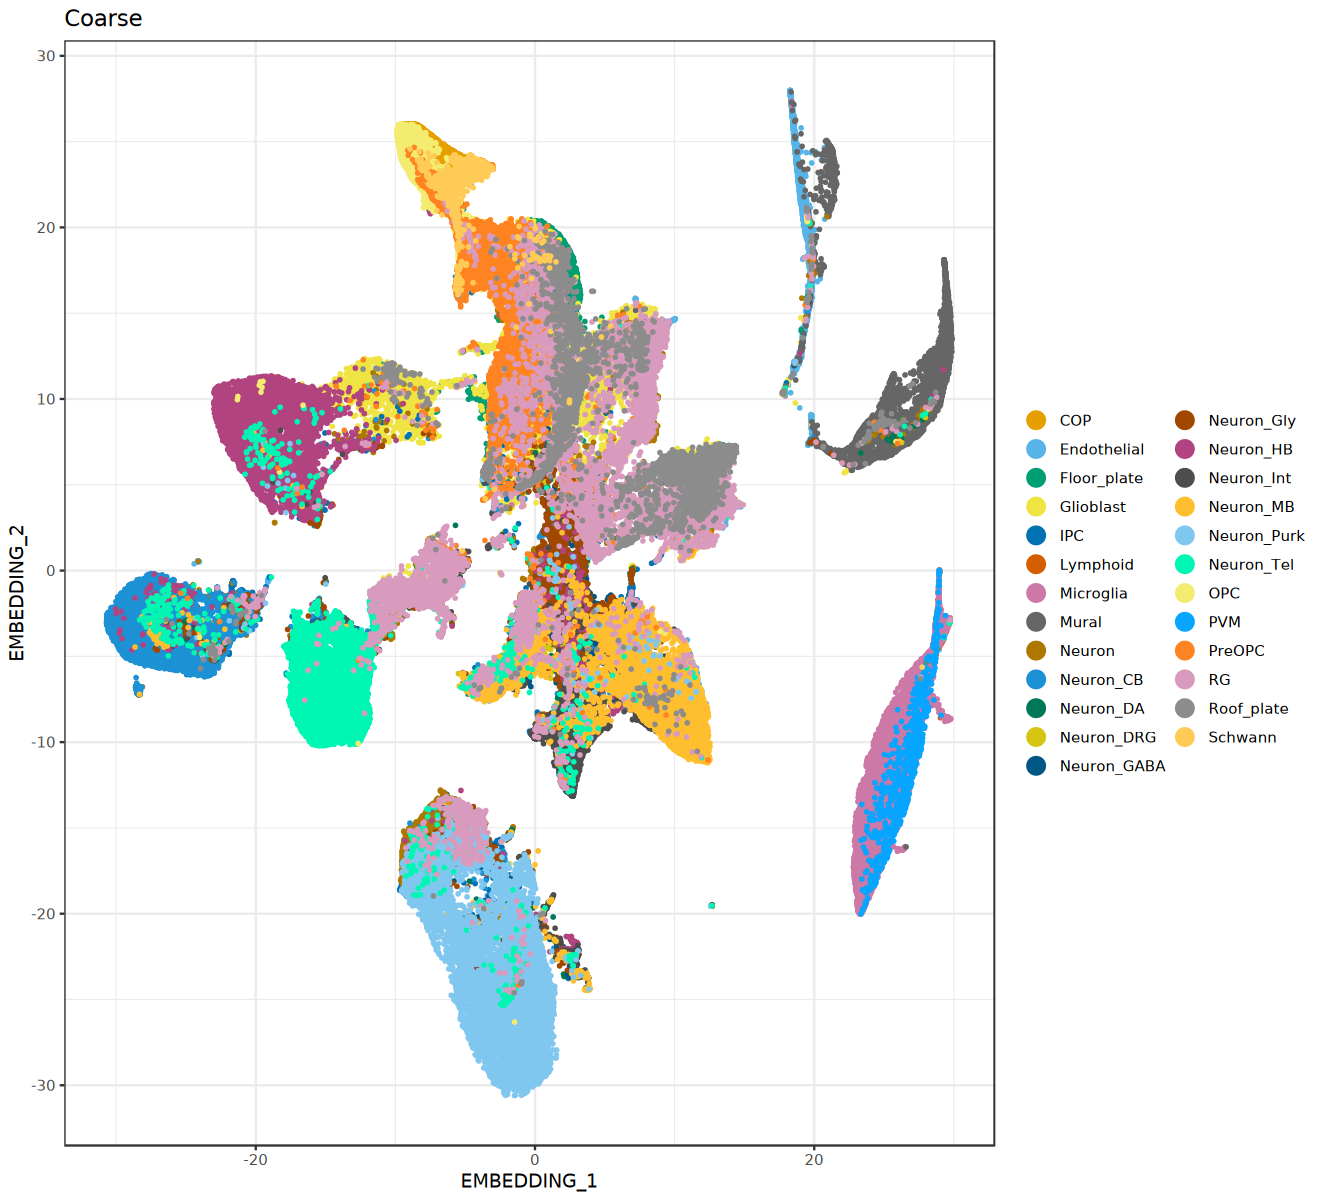

In [5]:
options(repr.plot.height = 10, repr.plot.width = 11)
dittoDimPlot(reference, var = 'Coarse', reduction.use = 'Embedding')

In [6]:
head(rownames(reference))

[1] "chr10-100006330-100006730" "chr10-100009752-100010152"
[3] "chr10-100016742-100017142" "chr10-100019767-100020167"
[5] "chr10-100020277-100020677" "chr10-100020878-100021278"

reference <- FindTopFeatures(reference, min.cutoff = 10)
reference <- RunTFIDF(reference)
reference <- RunSVD(reference)

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'

Found more than one class "dist" in cache; using the first, from namespace 'BiocGenerics'

Also defined by 'spam'



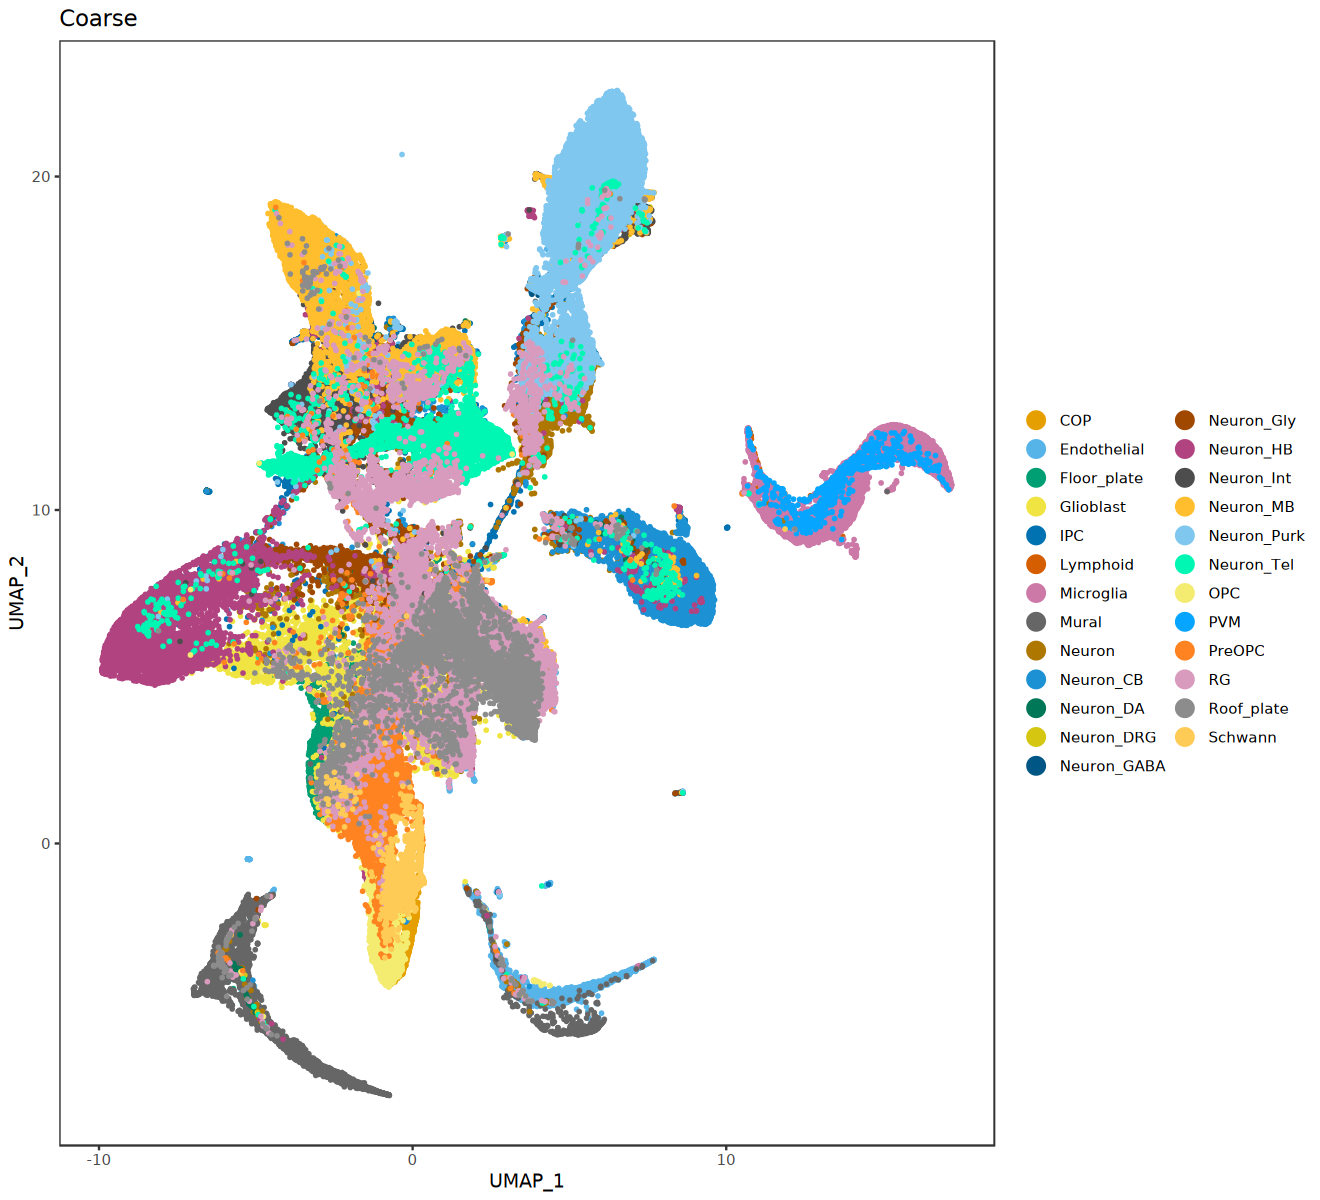

In [7]:
reference <- RunUMAP(reference, reduction = "LSI", dims = 2:30, return.model = TRUE, verbose=FALSE)
dittoDimPlot(reference, var = 'Coarse')

In [8]:
embedding <- Embeddings(reference, reduction = 'Embedding')

In [9]:
all(rownames(reference@reductions$umap@cell.embeddings) == rownames(embedding))

[1] TRUE

In [10]:
reference@reductions$umap@cell.embeddings <- embedding

In [11]:
reference@reductions$umap@misc$model$embedding <- embedding  %>% 
                                                    `colnames<-` (NULL)

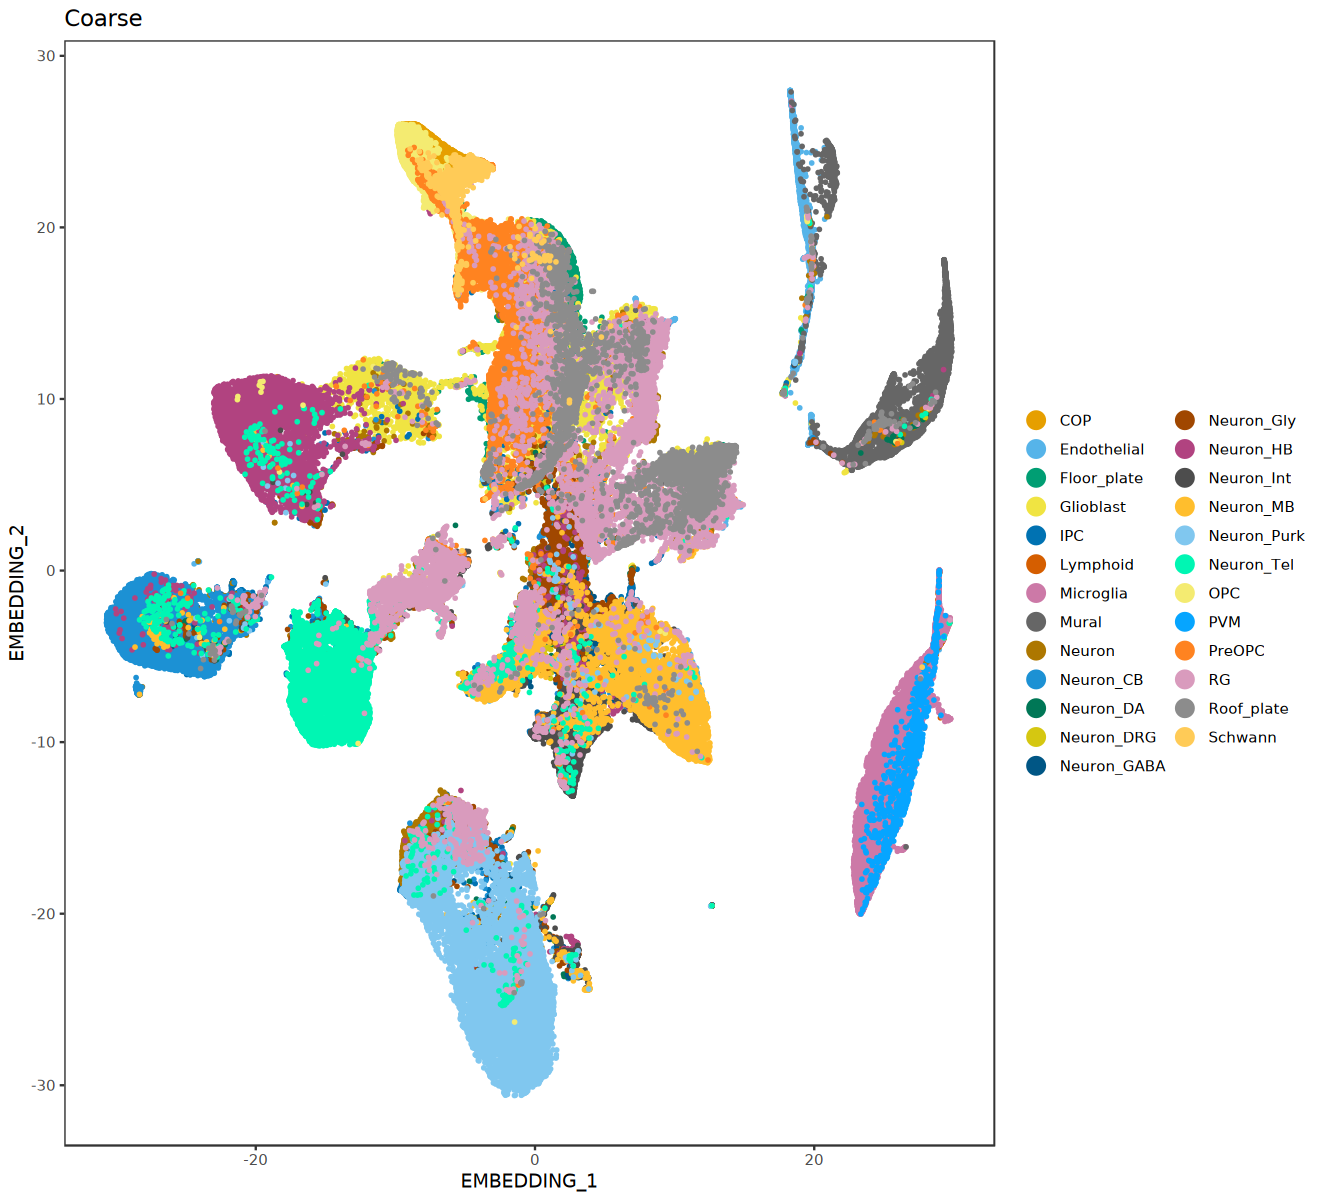

In [12]:
dittoDimPlot(reference, var = 'Coarse', reduction.use = 'umap')

In [13]:
dmg <- readRDS('../data/cca_integrated_atac_multiome_dmg_atlas_no_doublets.rds')
dmg

An object of class Seurat 
397376 features across 124594 samples within 2 assays 
Active assay: RNA (19607 features, 0 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 2 dimensional reductions calculated: integrated_lsi, umap

In [14]:
DefaultAssay(dmg) <- 'ATAC'
head(rownames(dmg))

[1] "chr1-9729-10741"    "chr1-15764-16590"   "chr1-17055-17946"  
[4] "chr1-28900-29821"   "chr1-180694-181903" "chr1-183749-184822"

In [15]:
atac_dmg_data <- GetAssayData(dmg, slot='counts')
fragpath <- '/projects/0/einf2548/cruiz/dmg/notebooks/scATAC/compiled_fragments/compiled_fragments.tsv.gz'

Warning message:
"The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead."


In [16]:
# Get gene annotations
annotation <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
# Change to UCSC style 
seqlevelsStyle(annotation) <- 'UCSC'

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [17]:
# Create ChromatinAssay for ATAC data
atac_dmg_assay <- CreateChromatinAssay(
  counts = atac_dmg_data,
  sep = c(":", "-"),
  fragments = fragpath,
  annotation = annotation
)

Computing hash



In [18]:
# Create ChromatinAssay for ATAC data
atac_dmg_assay <- CreateChromatinAssay(
  counts = atac_dmg_data,
  sep = c(":", "-"),
  fragments = fragpath,
  annotation = annotation
)

Computing hash



In [19]:
# Create ChromatinAssay for ATAC data
reference_chromatin <- CreateChromatinAssay(
  counts = GetAssayData(reference, slot = 'counts'),
  annotation = annotation
)

In [20]:
reference_chromatin

ChromatinAssay data with 410863 features for 180724 cells
Variable features: 0 
Genome: 
Annotation present: TRUE 
Motifs present: FALSE 
Fragment files: 0 

In [21]:
# Requantify query ATAC to have same features as multiome ATAC dataset
requant_multiome_ATAC <- FeatureMatrix(
  fragments = Fragments(atac_dmg_assay),
  features = granges(reference_chromatin),
  cells = Cells(atac_dmg_assay)
)

Extracting reads overlapping genomic regions



In [22]:
# Create assay with requantified ATAC data
ATAC_assay <- CreateChromatinAssay(
  counts = requant_multiome_ATAC,
  fragments = fragpath,
  annotation = annotation
)

Computing hash



In [23]:
# Create Seurat sbject
dmg.atac  <- CreateSeuratObject(counts = ATAC_assay,assay = 'ATAC')
dmg.atac[['peak.orig']] <- atac_dmg_assay

In [37]:
# compute LSI
dmg.atac <- FindTopFeatures(dmg.atac, min.cutoff = 10)
dmg.atac <- RunTFIDF(dmg.atac)
dmg.atac <- RunSVD(dmg.atac, n=40)

Running SVD

Scaling cell embeddings

Warning message:
"Number of dimensions changing from 50 to 40"


In [28]:
dmg.atac

An object of class Seurat 
788632 features across 124594 samples within 2 assays 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 1 other assay present: peak.orig
 1 dimensional reduction calculated: lsi

In [30]:
saveRDS(reference, 'reference.rds')
saveRDS(dmg.atac, 'dmg_atac.rds')

In [ ]:
reference <- readRDS('reference.rds')
dmg.atac <- readRDS('dmg_atac.rds')

In [ ]:
reference

In [5]:
reference <- DietSeurat(reference, dimreducs='umap')
reference

An object of class Seurat 
410863 features across 180724 samples within 1 assay 
Active assay: ATAC (410863 features, 0 variable features)
 2 layers present: counts, data
 1 dimensional reduction calculated: umap

In [6]:
reference <- FindTopFeatures(reference, min.cutoff = 10)

In [7]:
reference <- RunTFIDF(reference)
reference <- RunSVD(reference)

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings



In [8]:
saveRDS(reference, 'reference_diet.rds')

In [2]:
reference <- readRDS('reference_diet.rds')
dmg.atac <- readRDS('dmg_atac.rds')
reference
dmg.atac

An object of class Seurat 
410863 features across 180724 samples within 1 assay 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: umap, lsi

An object of class Seurat 
788632 features across 124594 samples within 2 assays 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 1 other assay present: peak.orig
 1 dimensional reduction calculated: lsi

In [8]:
max_cells_per_celltype = 2000

sampled.metadata <- reference@meta.data %>%
      tibble::rownames_to_column(., 'barcode2') %>%
      group_by(., Coarse) %>% 
      nest() %>%            
      mutate(n =  map_dbl(data, nrow)) %>%
      mutate(n = min(n, max_cells_per_celltype)) %>%
      ungroup() %>% 
      mutate(samp = map2(data, n, sample_n)) %>% 
      select(-data) %>%
      unnest(samp)

reference <- subset(reference, cells = sampled.metadata$barcode2)
reference

An object of class Seurat 
410863 features across 45046 samples within 1 assay 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 2 dimensional reductions calculated: umap, lsi

In [9]:
dmg.atac <- subset(dmg.atac, cells = sample(Cells(dmg.atac), 50000))
dmg.atac

An object of class Seurat 
788632 features across 50000 samples within 2 assays 
Active assay: ATAC (410863 features, 410863 variable features)
 2 layers present: counts, data
 1 other assay present: peak.orig
 1 dimensional reduction calculated: lsi

In [10]:
# find transfer anchors
transfer.anchors <- FindTransferAnchors(
  reference = reference,
  query = dmg.atac,
  reference.reduction = "lsi",
  reduction = "lsiproject",
  dims = 2:50
)

Projecting new data onto SVD

Finding neighborhoods

Finding anchors

	Found 8588 anchors



In [11]:
dmg.atac <- TransferData(
  anchorset = transfer.anchors, 
  reference = reference,
  weight.reduction = "lsiproject",
  query = dmg.atac,
  refdata = list(
    Predicted.coarse = "Coarse")
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"


In [12]:
dmg.atac <- IntegrateEmbeddings(
  anchorset = transfer.anchors,
  reference = reference,
  query = dmg.atac, 
  reductions = "lsiproject",
  new.reduction.name = "ref.lsi"
)

Warning message:
"Layer counts isn't present in the assay object; returning NULL"
Warning message:
"Layer counts isn't present in the assay object; returning NULL"

Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data



In [13]:
dmg.atac <- ProjectUMAP(
  query = dmg.atac, 
  query.reduction = "ref.lsi",
  reference = reference, 
  reference.reduction = "lsi",
  reduction.model = "umap"
)

Computing nearest neighbors

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
Running UMAP projection

09:43:11 Read 50000 rows

09:43:11 Processing block 1 of 1

09:43:11 Commencing smooth kNN distance calibration using 32 threads
 with target n_neighbors = 30

09:43:11 Initializing by weighted average of neighbor coordinates using 32 threads

09:43:11 Commencing optimization for 67 epochs, with 1500000 positive edges

09:43:33 Finished



In [15]:
dmg.atac@meta.data

,orig.ident,nCount_ATAC,nFeature_ATAC,nCount_peak.orig,nFeature_peak.orig,predicted.Predicted.coarse.score,predicted.Predicted.coarse
,<fct>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>
GNG_region_11_AAACAGCCAAAGCGGC-1,GNG,2025,1956,3517,3382,0.3129381,Neuron_Gly
GNG_region_11_AAACCAACATCATGTG-1,GNG,1894,1823,3833,3592,0.3842255,Neuron_Gly
GNG_region_11_AAACCAACATGATTGT-1,GNG,1209,1184,2067,1987,0.4293517,Neuron_Gly
GNG_region_11_AAACCGGCAGGCTACT-1,GNG,3709,3537,6235,5822,0.5611701,Schwann
GNG_region_11_AAACGCGCAAATTCGT-1,GNG,2720,2586,4500,4149,0.6999819,Microglia
GNG_region_11_AAACGCGCAATGAGGT-1,GNG,3257,3149,5330,5130,0.6328841,Neuron_Gly
GNG_region_11_AAACGCGCAGGAATCG-1,GNG,8148,7738,15035,13827,0.7062169,COP
GNG_region_11_AAACGCGCAGTTATCG-1,GNG,2055,1962,3395,3175,0.9337105,Mural
GNG_region_11_AAACGCGCATAAGGAC-1,GNG,4048,3801,6673,6024,0.6085849,Schwann


Warning message:
"ggrepel: 9 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


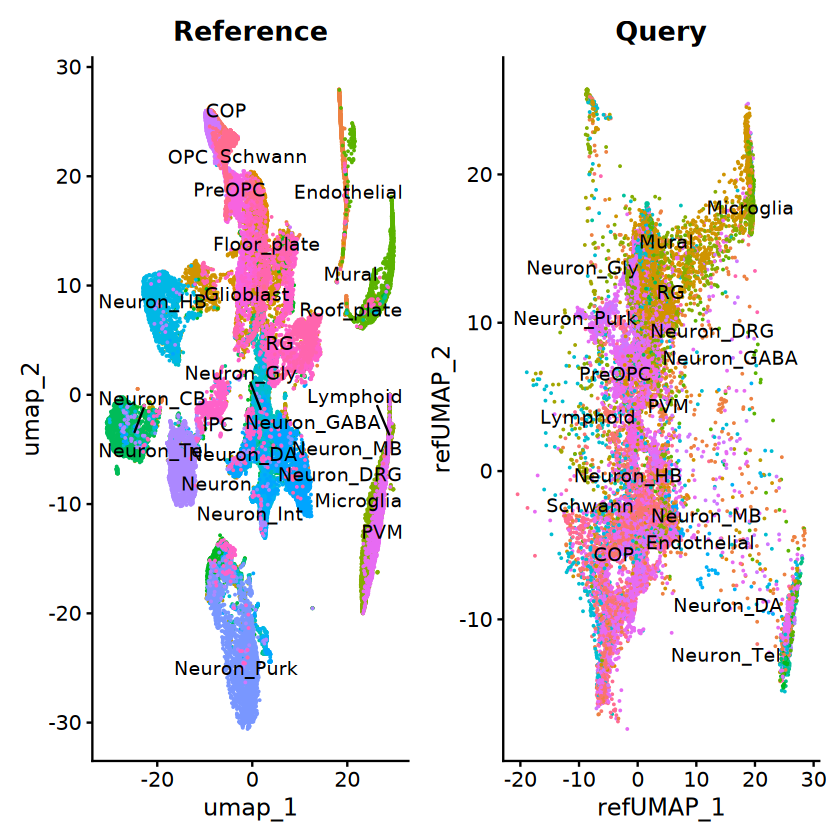

In [16]:
p1 <- DimPlot(reference, reduction = "umap", group.by = "Coarse", label = TRUE, repel = TRUE) + NoLegend() + ggtitle("Reference")
p2 <- DimPlot(dmg.atac, reduction = "ref.umap", group.by = "predicted.Predicted.coarse", label = TRUE, repel = TRUE) + NoLegend() + ggtitle("Query")

p1 | p2